In [3]:
import pandas as pd
import numpy as np

orders = pd.read_csv('../01-data/processed/cleaned_orders.csv')
order_items = pd.read_csv('../01-data/processed/cleaned_order_items.csv')

# Fix datetime columns
orders['created_at'] = pd.to_datetime(
    orders['created_at'],
    format='mixed',
    utc=True
)

order_items['created_at'] = pd.to_datetime(
    order_items['created_at'],
    format='mixed',
    utc=True
)

print("Orders Loaded:", orders.shape)
print("Order Items Loaded:", order_items.shape)

print("\nOrders Columns:")
print(orders.columns)

print("\nOrder Items Columns:")
print(order_items.columns)

Orders Loaded: (125226, 14)
Order Items Loaded: (181759, 15)

Orders Columns:
Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'order_completion_days',
       'is_returned', 'order_month', 'order_quarter', 'order_year'],
      dtype='object')

Order Items Columns:
Index(['id', 'order_id', 'user_id', 'product_id', 'inventory_item_id',
       'status', 'created_at', 'shipped_at', 'delivered_at', 'returned_at',
       'sale_price', 'sale_price_capped', 'product_master_id', 'cost',
       'gross_margin'],
      dtype='object')


In [4]:
# ==========================
# RFM TABLE CREATION
# ==========================

import pandas as pd
import numpy as np

# Analysis date
analysis_date = orders['created_at'].max()

# --------------------------
# RECENCY
# --------------------------

recency = (
    orders.groupby('user_id')['created_at']
    .max()
    .reset_index()
)

recency['recency_days'] = (
    analysis_date - recency['created_at']
).dt.days

recency = recency[
    ['user_id', 'recency_days']
]

# --------------------------
# FREQUENCY
# --------------------------

frequency = (
    orders.groupby('user_id')['order_id']
    .nunique()
    .reset_index()
)

frequency.columns = [
    'user_id',
    'frequency'
]

# --------------------------
# MONETARY
# --------------------------

monetary = (
    order_items.groupby('user_id')['sale_price']
    .sum()
    .reset_index()
)

monetary.columns = [
    'user_id',
    'monetary'
]

# --------------------------
# MERGE RFM
# --------------------------

rfm = (
    recency
    .merge(frequency, on='user_id')
    .merge(monetary, on='user_id')
)

print(rfm.shape)

rfm.head()

(80044, 4)


,user_id,recency_days,frequency,monetary
0,1,548,1,159.990000
1,2,696,1,22.000000
2,3,162,4,402.200001
3,4,456,1,148.000000
4,5,454,1,65.650000


In [5]:
# ==========================
# RFM SCORING
# ==========================

rfm['R_score'] = pd.qcut(
    rfm['recency_days'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

rfm.head()

,user_id,recency_days,frequency,monetary,R_score,F_score,M_score
0,1,548,1,159.990000,2,1,4
1,2,696,1,22.000000,1,1,1
2,3,162,4,402.200001,4,5,5
3,4,456,1,148.000000,2,1,4
4,5,454,1,65.650000,2,1,2


In [6]:
rfm['rfm_score'] = (
    rfm['R_score'].astype(str)
    +
    rfm['F_score'].astype(str)
    +
    rfm['M_score'].astype(str)
)

rfm[
    [
        'user_id',
        'R_score',
        'F_score',
        'M_score',
        'rfm_score'
    ]
].head()

,user_id,R_score,F_score,M_score,rfm_score
0,1,2,1,4,214
1,2,1,1,1,111
2,3,4,5,5,455
3,4,2,1,4,214
4,5,2,1,2,212


In [7]:
def assign_segment(row):

    R = row['R_score']
    F = row['F_score']
    M = row['M_score']

    if R >= 4 and F >= 4 and M >= 4:
        return 'Champions'

    elif F >= 4 and M >= 4:
        return 'Loyal Customers'

    elif R >= 4 and F >= 2:
        return 'Potential Loyalists'

    elif R <= 2 and M >= 4:
        return 'At Risk High Value'

    elif R >= 4 and F == 1:
        return 'New Users'

    elif R <= 2 and F <= 2 and M <= 2:
        return 'Dormant'

    else:
        return 'Others'

rfm['segment'] = rfm.apply(
    assign_segment,
    axis=1
)

rfm['segment'].value_counts()

segment
Others                 24044
Potential Loyalists    15588
Champions              11133
Loyal Customers        10045
Dormant                 8780
New Users               5347
At Risk High Value      5107
Name: count, dtype: int64

In [8]:
rfm.to_csv(
    'rfm_segments.csv',
    index=False
)

print(rfm.shape)

(80044, 9)


In [9]:
rfm['segment'].value_counts()

segment
Others                 24044
Potential Loyalists    15588
Champions              11133
Loyal Customers        10045
Dormant                 8780
New Users               5347
At Risk High Value      5107
Name: count, dtype: int64

In [10]:
rfm.head()

,user_id,recency_days,frequency,monetary,R_score,F_score,M_score,rfm_score,segment
0,1,548,1,159.990000,2,1,4,214,At Risk High Value
1,2,696,1,22.000000,1,1,1,111,Dormant
2,3,162,4,402.200001,4,5,5,455,Champions
3,4,456,1,148.000000,2,1,4,214,At Risk High Value
4,5,454,1,65.650000,2,1,2,212,Dormant


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

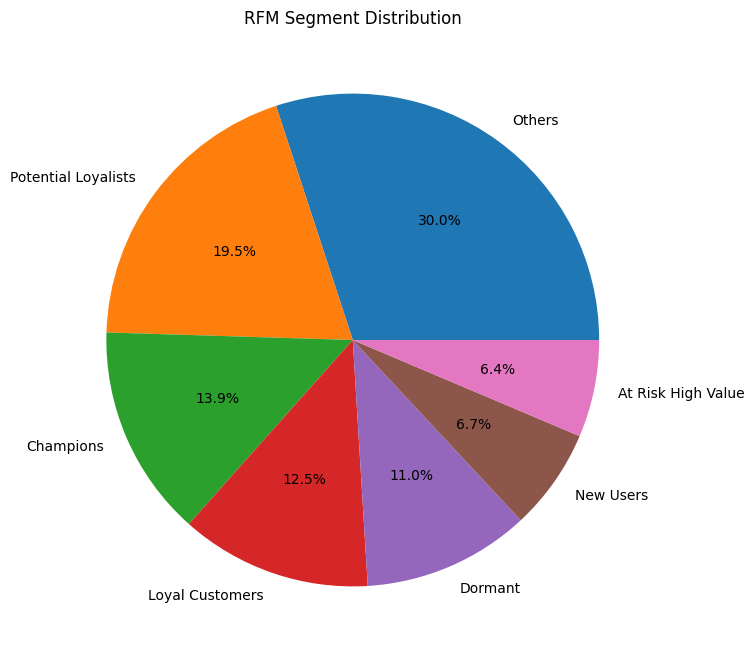

In [13]:
plt.figure(figsize=(10,8))

rfm['segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('RFM Segment Distribution')
plt.ylabel('')

plt.show()

In [14]:
events = pd.read_csv('../01-data/processed/cleaned_events.csv')
users = pd.read_csv('../01-data/processed/cleaned_users.csv')

print(events.shape)
print(users.shape)

print(events.columns)

(814748, 17)
(100000, 17)
Index(['id', 'user_id', 'sequence_number', 'session_id', 'created_at',
       'ip_address', 'city', 'state', 'postal_code', 'browser',
       'traffic_source', 'uri', 'event_type', 'funnel_stage', 'page_category',
       'event_hour', 'event_day_of_week'],
      dtype='object')


C:\Users\OM\AppData\Local\Temp\ipykernel_22160\3287739246.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv('../01-data/processed/cleaned_users.csv')


In [15]:
session_depth = (
    events.groupby(
        ['user_id', 'session_id']
    )['sequence_number']
    .max()
    .reset_index()
)

avg_session_depth = (
    session_depth.groupby('user_id')['sequence_number']
    .mean()
    .reset_index()
)

avg_session_depth.columns = [
    'user_id',
    'avg_session_depth'
]

avg_session_depth.head()

,user_id,avg_session_depth
0,1.0,10.0
1,2.0,5.0
2,3.0,5.8
3,4.0,5.0
4,5.0,10.0


In [16]:
categories_browsed = (
    events.groupby('user_id')['page_category']
    .nunique()
    .reset_index()
)

categories_browsed.columns = [
    'user_id',
    'categories_browsed'
]

categories_browsed.head()

,user_id,categories_browsed
0,1.0,4
1,2.0,5
2,3.0,5
3,4.0,5
4,5.0,4


In [17]:
carts = (
    events[
        events['event_type']
        .str.contains(
            'cart',
            case=False,
            na=False
        )
    ]
    .groupby('user_id')
    .size()
    .reset_index(name='carts')
)

purchases = (
    orders.groupby('user_id')
    .size()
    .reset_index(name='purchases')
)

cart_abandonment = (
    carts.merge(
        purchases,
        on='user_id',
        how='left'
    )
)

cart_abandonment['purchases'] = (
    cart_abandonment['purchases']
    .fillna(0)
)

cart_abandonment['cart_abandonment_rate'] = (
    cart_abandonment['carts']
    /
    (
        cart_abandonment['carts']
        +
        cart_abandonment['purchases']
    )
)

cart_abandonment.head()

,user_id,carts,purchases,cart_abandonment_rate
0,1.0,3,1,0.750000
1,2.0,1,1,0.500000
2,3.0,5,4,0.555556
3,4.0,1,1,0.500000
4,5.0,3,1,0.750000


In [18]:
orders_sorted = (
    orders.sort_values(
        ['user_id', 'created_at']
    )
)

orders_sorted['days_between_orders'] = (
    orders_sorted.groupby('user_id')['created_at']
    .diff()
    .dt.days
)

avg_days_between_orders = (
    orders_sorted.groupby('user_id')['days_between_orders']
    .mean()
    .reset_index()
)

avg_days_between_orders.head()

,user_id,days_between_orders
0,1,NaN
1,2,NaN
2,3,50.333333
3,4,NaN
4,5,NaN


In [19]:
# ==========================
# FINAL USER FEATURE TABLE
# ==========================

user_features = (

    rfm

    .merge(
        avg_session_depth,
        on='user_id',
        how='left'
    )

    .merge(
        categories_browsed,
        on='user_id',
        how='left'
    )

    .merge(
        cart_abandonment[
            ['user_id','cart_abandonment_rate']
        ],
        on='user_id',
        how='left'
    )

    .merge(
        avg_days_between_orders,
        on='user_id',
        how='left'
    )

)

user_features.head()

,user_id,recency_days,frequency,monetary,R_score,F_score,M_score,rfm_score,segment,avg_session_depth,categories_browsed,cart_abandonment_rate,days_between_orders
0,1,548,1,159.990000,2,1,4,214,At Risk High Value,10.0,4,0.750000,NaN
1,2,696,1,22.000000,1,1,1,111,Dormant,5.0,5,0.500000,NaN
2,3,162,4,402.200001,4,5,5,455,Champions,5.8,5,0.555556,50.333333
3,4,456,1,148.000000,2,1,4,214,At Risk High Value,5.0,5,0.500000,NaN
4,5,454,1,65.650000,2,1,2,212,Dormant,10.0,4,0.750000,NaN


In [20]:
user_features['avg_session_depth'] = (
    user_features['avg_session_depth']
    .fillna(0)
)

user_features['categories_browsed'] = (
    user_features['categories_browsed']
    .fillna(0)
)

user_features['cart_abandonment_rate'] = (
    user_features['cart_abandonment_rate']
    .fillna(0)
)

user_features['days_between_orders'] = (
    user_features['days_between_orders']
    .fillna(0)
)

user_features.isnull().sum()

user_id                  0
recency_days             0
frequency                0
monetary                 0
R_score                  0
F_score                  0
M_score                  0
rfm_score                0
segment                  0
avg_session_depth        0
categories_browsed       0
cart_abandonment_rate    0
days_between_orders      0
dtype: int64

In [21]:
kmeans_features = user_features[

    [

        'recency_days',

        'frequency',

        'monetary',

        'avg_session_depth',

        'categories_browsed',

        'cart_abandonment_rate',

        'days_between_orders'

    ]

]

kmeans_features.head()

,recency_days,frequency,monetary,avg_session_depth,categories_browsed,cart_abandonment_rate,days_between_orders
0,548,1,159.990000,10.0,4,0.750000,0.000000
1,696,1,22.000000,5.0,5,0.500000,0.000000
2,162,4,402.200001,5.8,5,0.555556,50.333333
3,456,1,148.000000,5.0,5,0.500000,0.000000
4,454,1,65.650000,10.0,4,0.750000,0.000000


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    kmeans_features
)

scaled_features.shape

(80044, 7)

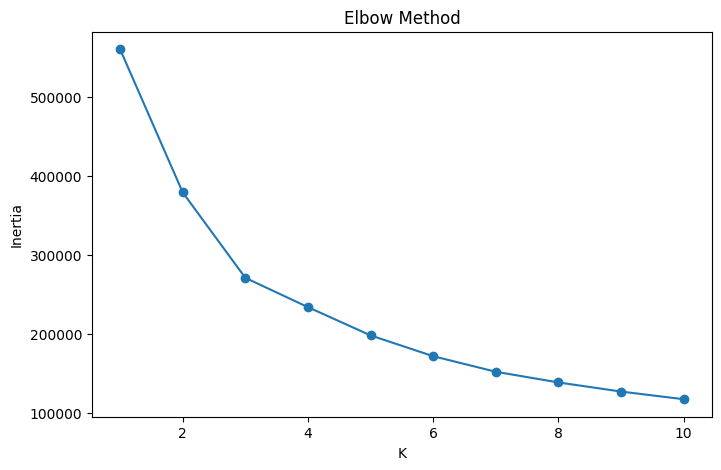

In [23]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(
        scaled_features
    )

    inertia.append(
        model.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

user_features['cluster'] = kmeans.fit_predict(
    scaled_features
)

user_features['cluster'].value_counts()

cluster
2    31695
0    16416
1    12536
3    12349
4     7048
Name: count, dtype: int64

In [25]:
cluster_profile = user_features.groupby('cluster')[

    [
        'recency_days',
        'frequency',
        'monetary',
        'avg_session_depth',
        'categories_browsed',
        'cart_abandonment_rate',
        'days_between_orders'
    ]

].median().round(2)

cluster_profile

,recency_days,frequency,monetary,avg_session_depth,categories_browsed,cart_abandonment_rate,days_between_orders
cluster,,,,,,,
0,316.5,1.0,127.99,7.00,4.0,0.67,0.00
1,900.0,1.0,45.00,5.00,5.0,0.50,0.00
2,165.0,1.0,50.00,5.00,5.0,0.50,0.00
3,130.0,3.0,283.95,6.33,5.0,0.60,150.33
4,236.0,2.0,129.00,5.00,5.0,0.50,577.75


In [26]:
cluster_size = (
    user_features['cluster']
    .value_counts()
    .sort_index()
)

cluster_size

cluster
0    16416
1    12536
2    31695
3    12349
4     7048
Name: count, dtype: int64

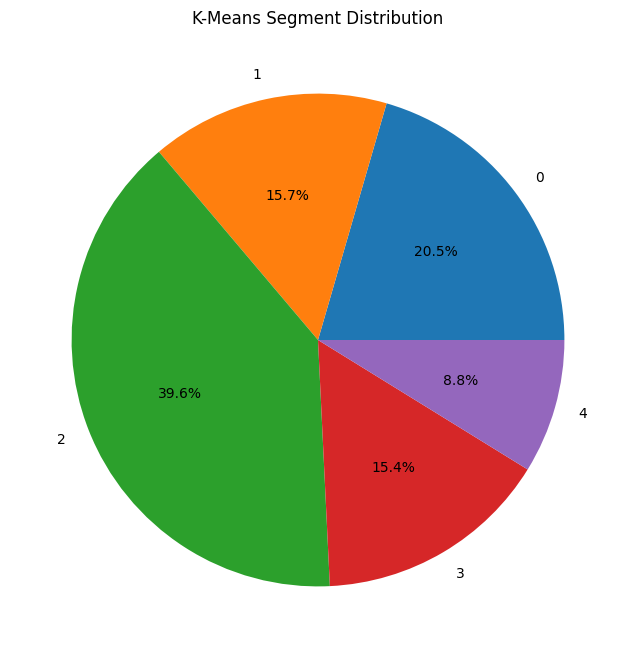

In [27]:
plt.figure(figsize=(8,8))

cluster_size.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title(
    'K-Means Segment Distribution'
)

plt.ylabel('')

plt.show()

In [28]:
segment_revenue = (
    user_features.groupby('cluster')
    .agg(
        users=('user_id','count'),
        avg_ltv=('monetary','mean')
    )
)

segment_revenue['revenue_potential'] = (
    segment_revenue['users']
    *
    segment_revenue['avg_ltv']
)

segment_revenue

,users,avg_ltv,revenue_potential
cluster,,,
0,16416,161.369922,2.649049e+06
1,12536,65.842640,8.254033e+05
2,31695,70.472061,2.233612e+06
3,12349,328.622447,4.058159e+06
4,7048,150.524458,1.060896e+06


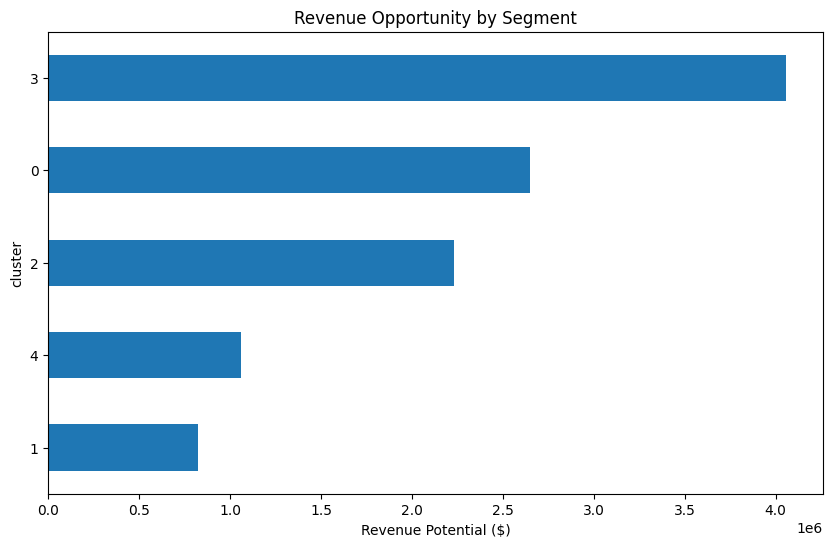

In [29]:
plt.figure(figsize=(10,6))

segment_revenue['revenue_potential'].sort_values().plot(
    kind='barh'
)

plt.title(
    'Revenue Opportunity by Segment'
)

plt.xlabel('Revenue Potential ($)')

plt.show()

Users: 12,349
Median Orders: 3
Median Revenue: $283.95
Lowest Recency: 130 days
Highest Revenue Potential: $4.06M

Users: 16,416
Revenue Potential: $2.65M
Median Spend: $127.99
Recency: 316 days

Users: 31,695
Largest segment (39.6%)
Revenue Potential: $2.23M

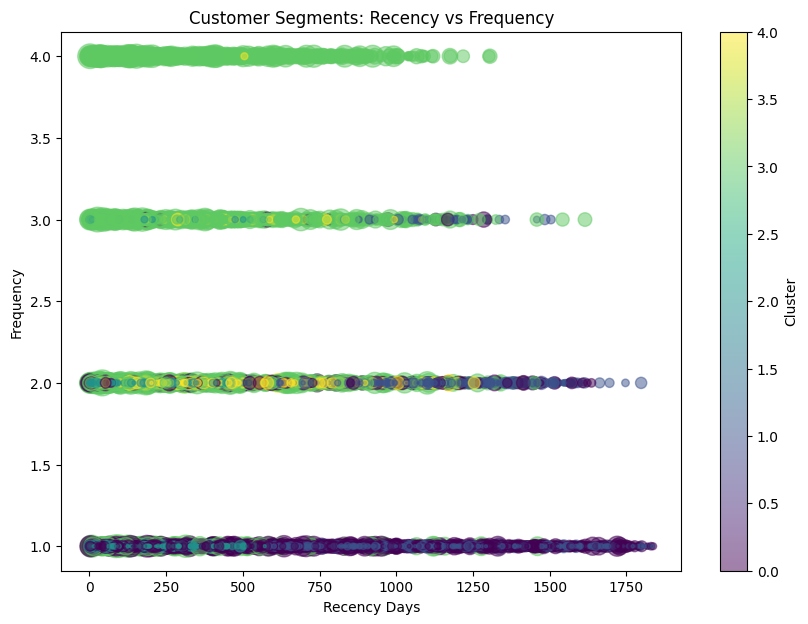

In [30]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    user_features['recency_days'],
    user_features['frequency'],
    c=user_features['cluster'],
    s=user_features['monetary']/5,
    alpha=0.5
)

plt.xlabel('Recency Days')
plt.ylabel('Frequency')

plt.title(
    'Customer Segments: Recency vs Frequency'
)

plt.colorbar(label='Cluster')

plt.show()

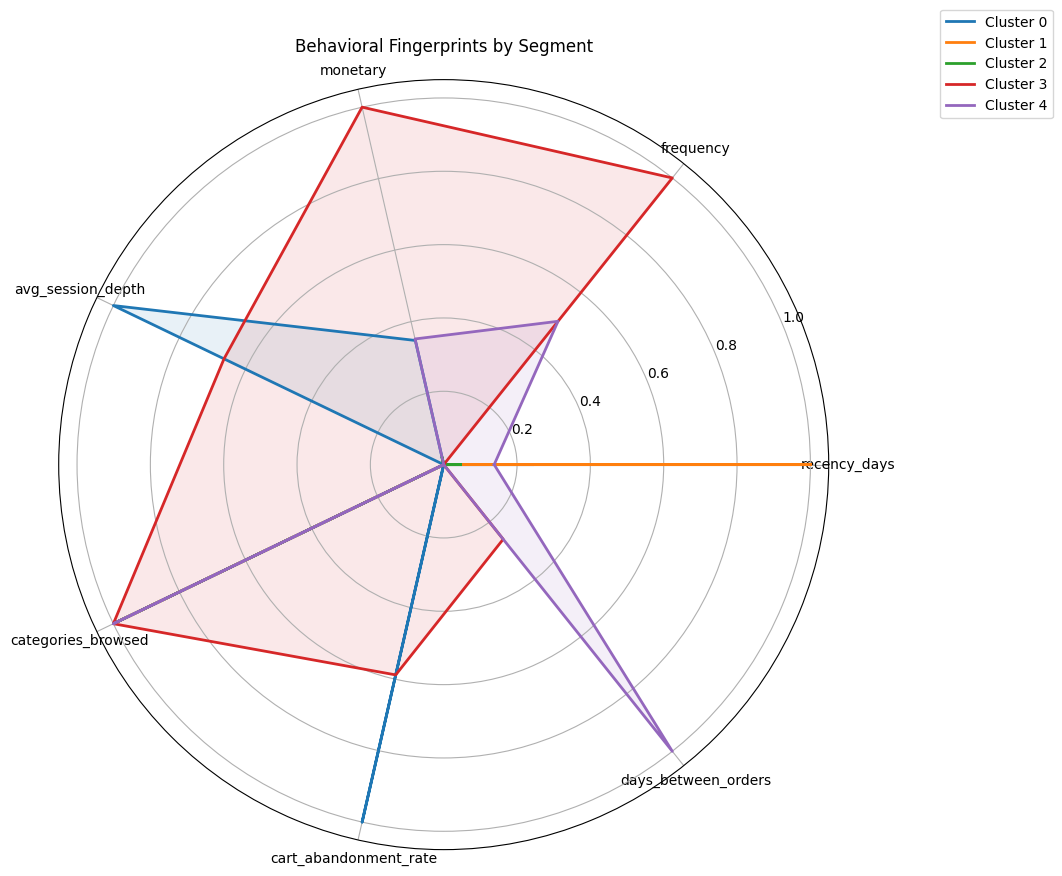

In [31]:
import numpy as np

radar_data = cluster_profile.copy()

# Normalize for radar chart
radar_norm = (
    radar_data - radar_data.min()
) / (
    radar_data.max() - radar_data.min()
)

features = radar_norm.columns.tolist()

angles = np.linspace(
    0,
    2*np.pi,
    len(features),
    endpoint=False
).tolist()

angles += angles[:1]

plt.figure(figsize=(10,10))

ax = plt.subplot(111, polar=True)

for cluster in radar_norm.index:

    values = radar_norm.loc[cluster].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f'Cluster {cluster}'
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    features,
    fontsize=10
)

plt.title(
    'Behavioral Fingerprints by Segment',
    pad=20
)

plt.legend(
    bbox_to_anchor=(1.3,1.1)
)

plt.show()

Radar Chart Interpretation
Cluster 3 — Champions
Highest frequency
Highest monetary value
Highest category exploration
Strong repeat behavior

Business Action: VIP loyalty program, premium recommendations.

Cluster 0 — At-Risk High Value
High session depth
High cart abandonment
Lower purchase frequency

Business Action: Checkout recovery campaigns and personalized offers.

Cluster 2 — Active Low-Value Users
Largest segment (39.6%)
Recent activity
Low spend

Business Action: Upsell and bundle strategies.

Cluster 1 — Dormant Users
Highest recency
Lowest monetary value
Minimal engagement

Business Action: Low-cost remarketing only.

Cluster 4 — Loyal Mid-Value Users
Moderate spend
Long order cycles
Consistent engagement

Business Action: Membership and subscription programs.

In [32]:
events['event_type'].value_counts()

event_type
cart          181759
department    181759
product       181759
purchase      181759
home           87712
Name: count, dtype: int64

In [33]:
event_metrics = (
    events.groupby('user_id')
    .agg(
        product_views=('event_type', lambda x: (x=='product').sum()),
        cart_events=('event_type', lambda x: (x=='cart').sum()),
        purchases=('event_type', lambda x: (x=='purchase').sum()),
        sessions=('session_id','nunique')
    )
    .reset_index()
)

event_metrics.head()

,user_id,product_views,cart_events,purchases,sessions
0,1.0,3,3,3,3
1,2.0,1,1,1,1
2,3.0,5,5,5,5
3,4.0,1,1,1,1
4,5.0,3,3,3,3


In [34]:
window_shoppers = event_metrics[
    (event_metrics['product_views'] >= 3) &
    (event_metrics['sessions'] >= 2) &
    (event_metrics['purchases'] == 0)
]

intent_buyers = event_metrics[
    (event_metrics['product_views'] >= 3) &
    (event_metrics['cart_events'] >= 1) &
    (event_metrics['purchases'] >= 1)
]

print("Window Shoppers:", len(window_shoppers))
print("Intent Buyers:", len(intent_buyers))

Window Shoppers: 0
Intent Buyers: 25435


In [35]:
comparison = pd.DataFrame({

    'Metric': [
        'Avg Product Views',
        'Avg Sessions',
        'Avg Cart Events',
        'Avg Purchases'
    ],

    'Window Shopper': [

        window_shoppers['product_views'].mean(),
        window_shoppers['sessions'].mean(),
        window_shoppers['cart_events'].mean(),
        window_shoppers['purchases'].mean()

    ],

    'Intent Buyer': [

        intent_buyers['product_views'].mean(),
        intent_buyers['sessions'].mean(),
        intent_buyers['cart_events'].mean(),
        intent_buyers['purchases'].mean()

    ]

})

comparison

,Metric,Window Shopper,Intent Buyer
0,Avg Product Views,NaN,4.227914
1,Avg Sessions,NaN,4.227914
2,Avg Cart Events,NaN,4.227914
3,Avg Purchases,NaN,4.227914


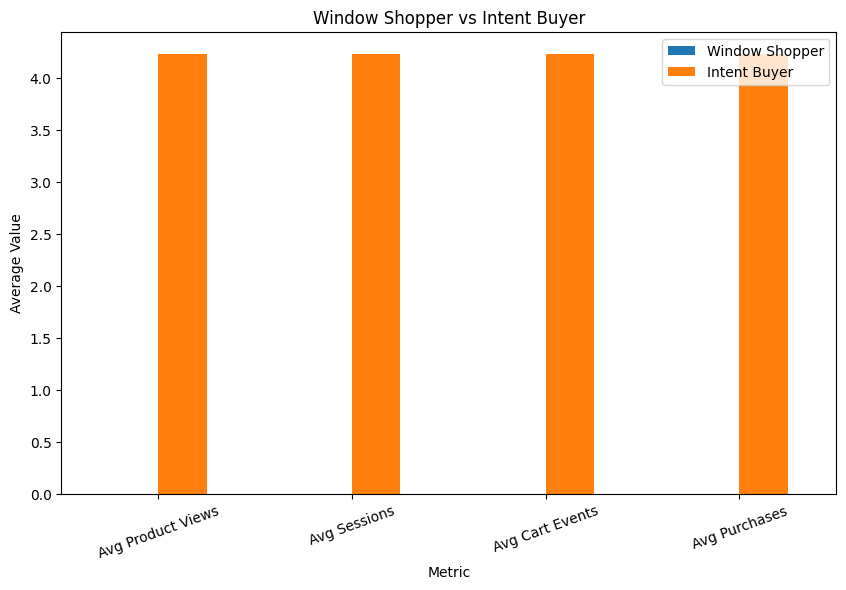

In [36]:
comparison_plot = comparison.set_index('Metric')

comparison_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Window Shopper vs Intent Buyer'
)

plt.ylabel('Average Value')

plt.xticks(rotation=20)

plt.show()

In [37]:
session_paths = (

    events.sort_values(
        ['session_id','sequence_number']
    )

    .groupby('session_id')['event_type']

    .apply(
        lambda x: ' → '.join(x.unique())
    )

    .reset_index()

)

session_paths.head()

,session_id,event_type
0,0000364a-ce41-46f1-89d6-3f8704af77db,home → department → product → cart → purchase
1,00004e02-6372-47a6-aaf7-f231de654979,home → department → product → cart → purchase
2,0000ffb8-8226-45e5-b4a7-a36872cf32c0,home → department → product → cart → purchase
3,0000ffe1-9aba-4da4-b11b-98a245007ac8,home → department → product → cart → purchase
4,0002a65e-3a50-405a-8f54-d9389c8a0b82,department → product → cart → purchase


In [38]:
top_paths = (

    session_paths['event_type']

    .value_counts()

    .head(10)

    .reset_index()

)

top_paths.columns = [
    'path',
    'sessions'
]

top_paths

,path,sessions
0,home → department → product → cart → purchase,87712
1,department → product → cart → purchase,39886
2,product → cart → department → purchase,13048
3,department → cart → product → purchase,12999
4,cart → department → product → purchase,12904
5,product → department → cart → purchase,12862
6,cart → product → department → purchase,2348


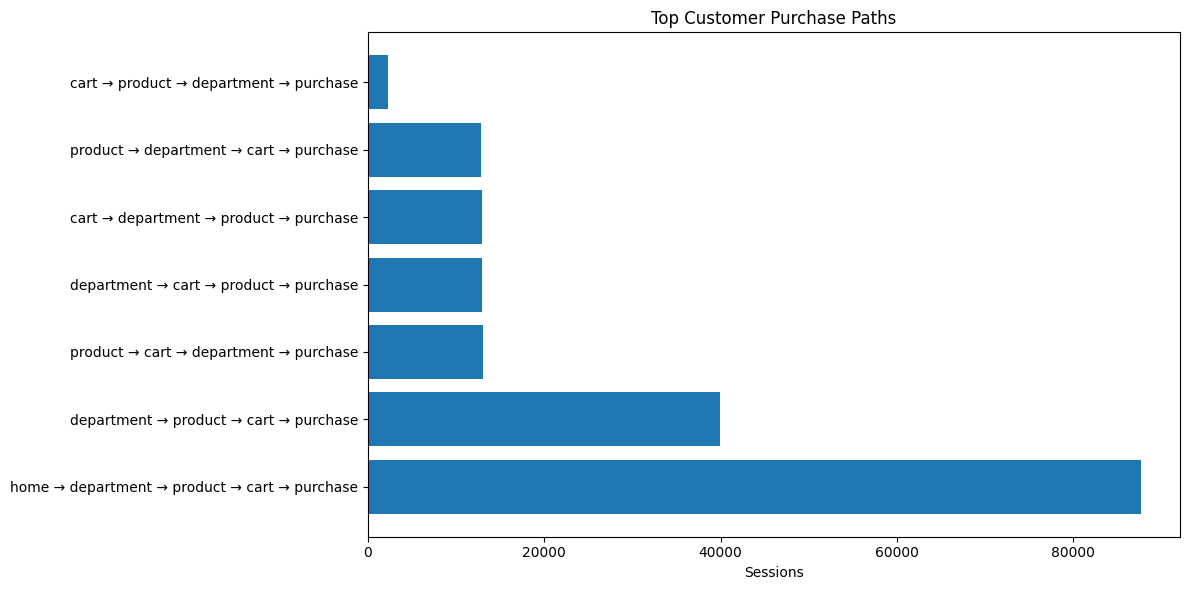

In [39]:
plt.figure(figsize=(12,6))

plt.barh(
    top_paths['path'],
    top_paths['sessions']
)

plt.title(
    'Top Customer Purchase Paths'
)

plt.xlabel(
    'Sessions'
)

plt.tight_layout()

plt.show()

In [40]:
user_features.to_csv(
    'user_segments_kmeans.csv',
    index=False
)

cluster_profile.to_csv(
    'segment_profiles.csv'
)

print("Files Saved Successfully")

Files Saved Successfully
